Trying xgboost on full dataset 4/29/2022
tutorial : https://www.datacamp.com/community/tutorials/xgboost-in-python

Load Packages

In [8]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Import dataset

In [2]:
X = np.load('X.npy')
y = np.load('y.npy')
y_split = np.hsplit(y, 2)

In [3]:
data_dmatrix = xgb.DMatrix(data=X,label=y)

In [4]:
#split training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [ ]:
#set up xgboost regressor
xg_reg = xgb.XGBRegressor(objective ='reg:squarederror', colsample_bytree = 0.3, learning_rate = 0.1,
                max_depth = 5, alpha = 10, n_estimators = 10)

In [ ]:
#fit the regressor
xg_reg.fit(X_train,y_train)

preds = xg_reg.predict(X_test)

In [ ]:
#compute rmse
rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE: %f" % (rmse))

RMSE: 31.142947


In [ ]:
#create dictionary to store hyperparameters

params = {"objective":"reg:squarederror",'colsample_bytree': 0.3,'learning_rate': 0.1,
                'max_depth': 5, 'alpha': 10}

#cross validation
cv_results = xgb.cv(dtrain=data_dmatrix, params=params, nfold=10,
                    num_boost_round=50,early_stopping_rounds=10,metrics="rmse", as_pandas=True, seed=123)

In [9]:
#cv_results contains train and test RMSE metrics for each boosting round.

cv_results.head()

,train-rmse-mean,train-rmse-std,test-rmse-mean,test-rmse-std
0,80.327105,0.038971,80.326390,0.393086
1,72.318023,0.034133,72.317239,0.394034
2,65.110353,0.030038,65.107116,0.388659
3,58.621333,0.027719,58.613766,0.369110
4,52.782991,0.024546,52.776210,0.359085


In [10]:
#Extract and print the final boosting round metric.

print((cv_results["test-rmse-mean"]).tail(1))

49    1.038143
Name: test-rmse-mean, dtype: float64


In [ ]:
##what if we do kmeans clustering for each site and then do categorical xgboost to predict into sites? i.e. https://medium.com/@khadijamahanga/using-latitude-and-longitude-data-in-my-machine-learning-problem-541e2651e08c
## 6/30
## all california would be one site, then divide between the sky islands


QUESTION: What does this mean? is 1.038 a good rmse?

tutorial: https://towardsdatascience.com/binary-classification-xgboost-hyperparameter-tuning-scenarios-by-non-exhaustive-grid-search-and-c261f4ce098d

In [11]:
#creating deepcopy of model instances
from copy import deepcopy

#array manipulations
import numpy as np

#dataframe and its manipulations
import pandas as pd

#plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

#selected plotting functions
#from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

#classes for grid search and cross-validation, function for splitting data and evaluating models
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV,train_test_split
#from skopt import BayesSearchCV
from sklearn.metrics import accuracy_score,f1_score,roc_auc_score,confusion_matrix,roc_curve

#XGBoost library
import xgboost as xgb

#Python standard libraries
import time
import warnings

#setting default resolution of figures
mpl.rcParams['figure.dpi'] = 200


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [13]:
xg_reg.fit(X_train , y_train)

#extracting default parameters from benchmark model
default_params = {}
gparams = xg_reg.get_params()

In [14]:
#creating deepcopy of default parameters before manipulations
params = deepcopy(default_params)

#setting grid of selected parameters for iteration
param_grid = {'gamma': [0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4, 200],
              'learning_rate': [0.01, 0.03, 0.06, 0.1, 0.15, 0.2, 0.25, 0.300000012, 0.4, 0.5, 0.6, 0.7],
              'max_depth': [5,6,7,8,9,10,11,12,13,14],
              'n_estimators': [50,65,80,100,115,130,150],
              'reg_alpha': [0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4,200],
              'reg_lambda': [0,0.1,0.2,0.4,0.8,1.6,3.2,6.4,12.8,25.6,51.2,102.4,200]}

In [15]:
#start time
t0 = time.time()
#No. of jobs
gcvj = np.cumsum([len(x) for x in param_grid.values()])[-1]

#iteration loop. Each selected parameter iterated separately
for i,grid_key in enumerate(param_grid.keys()):
    
    #variable for measuring iteration time
    loop_start = time.time()
       
    #creating param_grid argument for GridSearchCV:
    #listing grid values of current iterable parameter and wrapping non-iterable parameter single values in list
    for param_key in params.keys():
        if param_key == grid_key:
            params[param_key] = param_grid[grid_key]
        else:
            #use best parameters of last iteration
            try:
                param_value = [clf.best_params_[param_key]]
                params[param_key] = param_value
            #use benchmark model parameters for first iteration
            except:
                param_value = [clf0.best_params_[param_key]]
                params[param_key] = param_value
    
    #classifier instance of current iteration
    xgbc = xgb.XGBClassifier(**default_params)
    
    #GridSearch instance of current iteration
    clf = GridSearchCV(estimator=xgbc, param_grid=params, scoring='accuracy', return_train_score=True, verbose=1, cv=3)
    clf.fit(X_train, y_train)
    
    #results dataframe
    df = pd.DataFrame(clf.cv_results_)
    
    #predictions - inputs to confusion matrix
    train_predictions = clf.predict(X_train)
    test_predictions = clf.predict(X_test)
    unseen_predictions = clf.predict(df_test.iloc[:,1:])
    
    #confusion matrices
    cfm_train = confusion_matrix(y_train, train_predictions)
    cfm_test = confusion_matrix(y_test, test_predictions)
    cfm_unseen = confusion_matrix(df_test.iloc[:,:1], unseen_predictions)
    
    #accuracy scores
    accs_train = accuracy_score(y_train, train_predictions)
    accs_test = accuracy_score(y_test, test_predictions)
    accs_unseen = accuracy_score(df_test.iloc[:,:1], unseen_predictions)
    
    #F1 scores for each train/test label
    f1s_train_p1 = f1_score(y_train, train_predictions, pos_label=1)
    f1s_train_p0 = f1_score(y_train, train_predictions, pos_label=0)
    f1s_test_p1 = f1_score(y_test, test_predictions, pos_label=1)
    f1s_test_p0 = f1_score(y_test, test_predictions, pos_label=0)
    f1s_unseen_p1 = f1_score(df_test.iloc[:,:1], unseen_predictions, pos_label=1)
    f1s_unseen_p0 = f1_score(df_test.iloc[:,:1], unseen_predictions, pos_label=0)
    
    #Area Under the Receiver Operating Characteristic Curve
    test_ras = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])
    unseen_ras = roc_auc_score(df_test.iloc[:,:1], clf.predict_proba(df_test.iloc[:,1:])[:,1])
    
    #best parameters
    bp = clf.best_params_
    
    #storing computed values in results dictionary
    results_dict[f'xgbc{i+1}'] = {'iterable_parameter': grid_key,
                                  'classifier': deepcopy(clf),
                                  'cv_results': df.copy(),
                                  'cfm_train': cfm_train,
                                  'cfm_test': cfm_test,
                                  'cfm_unseen': cfm_unseen,
                                  'train_accuracy': accs_train,
                                  'test_accuracy': accs_test,
                                  'unseen_accuracy': accs_unseen,
                                  'train F1-score label 1': f1s_train_p1,
                                  'train F1-score label 0': f1s_train_p0,
                                  'test F1-score label 1': f1s_test_p1,
                                  'test F1-score label 0': f1s_test_p0,
                                  'unseen F1-score label 1': f1s_unseen_p1,
                                  'unseen F1-score label 0': f1s_unseen_p0,
                                  'test roc auc score': test_ras,
                                  'unseen roc auc score': unseen_ras,
                                  'best_params': bp}
    
    #variable for measuring iteration time
    elapsed_time = time.time() - loop_start
    print(f'iteration #{i+1} finished in: {elapsed_time} seconds')

#stop time
t1 = time.time()

#elapsed time
gcvt = t1 - t0

Fitting 3 folds for each of 1 candidates, totalling 3 fits


C:\Users\rah10\miniconda3\lib\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning: 
3 fits failed out of a total of 3.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\rah10\miniconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\rah10\miniconda3\lib\site-packages\xgboost\core.py", line 532, in inner_f
    return f(**kwargs)
  File "C:\Users\rah10\miniconda3\lib\site-packages\xgboost\sklearn.py", line 1357, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expected: [ 0  1  2

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66], got [-121.9974158  -121.9907972  -121.985363   -121.984531   -121.980569
 -121.971003   -121.9686889  -121.968234   -121.9535178  -121.943613
 -121.9396055  -121.8905656  -121.83358    -121.748527   -121.6785055
 -109.87794    -109.32636    -109.32601    -109.32533    -109.27945
 -107.59966    -107.59946    -107.59916    -107.59861    -107.18407
 -107.18371    -107.18359    -106.44305    -106.44238    -106.44234
 -105.64057    -105.63979    -105.63925      31.91721      32.66931
   33.63195      33.63202      33.63233      33.99009      33.99105
   33.99193      35.20518      35.2058       35.20589      35.24685
   35.24711      35.24745      35.24837      35.85482      35.85509
   35.8555       38.545401     

In [ ]:
from sklearn.multioutput import MultiOutputRegressor

#Define the estimator
estimator = xg_reg

# Define the model
my_model = MultiOutputRegressor(estimator = estimator, n_jobs = -1).fit(X_train, y_train)

try this https://forum.numer.ai/t/gradient-boosting-machines-for-multi-target-regression/4417

5/5 

In [8]:
from sklearn.multioutput import MultiOutputRegressor

In [9]:
multioutputregressor = MultiOutputRegressor(xgb.XGBRegressor(objective='reg:squarederror', colsample_bytree = 0.3, learning_rate = 0.1,
                max_depth = 5, alpha = 10, n_estimators = 10))

In [10]:
multioutputregressor.fit(X_train,y_train)
preds = multioutputregressor.predict(X_test)

In [11]:
rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE: %f" % (rmse))

RMSE: 31.161070


https://blog.cambridgespark.com/hyperparameter-tuning-in-xgboost-4ff9100a3b2f

In [12]:
#XGBoost uses DMatrices. A DMatrix can contain both the features and the target. If you already have loaded you data into numpy arrays X and y, you can create a DMatrix with:
xgb.DMatrix(X, label=y)

In [13]:
#We keep 90% of the dataset for training, and 10% (or a .1 part) for testing.
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.1, random_state=42)

In [14]:
#in order to use the native API for XGBoost, we will first need to build DMatrices.

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [15]:
#We are going to use mean absolute error (MAE) to evaluate the quality of our predictions. 
#MAE is a common and simple metric that has the advantage of being in the same unit as our target, which means it can be compared to target values and easily interpreted.
from sklearn.metrics import mean_absolute_error

In [16]:
#In order to get an idea of the range of MAE we would like to achieve here, 
#we are going to build a baseline model, and save its score for later. This score is what we can achieve with no efforts, so we hope we will beat it with our fancy algorithm.

# "Learn" the mean from the training data
mean_train = np.mean(y_train)
# Get predictions on the test set
baseline_predictions = np.ones(y_test.shape) * mean_train
# Compute MAE
mae_baseline = mean_absolute_error(y_test, baseline_predictions)
print("Baseline MAE is {:.2f}".format(mae_baseline))

Baseline MAE is 79.02


In [17]:
#Most of the parameters passed to XGBoost via the native API are defined in a dictionary.

params = {
    # Parameters that we are going to tune.
    'max_depth':6,
    'min_child_weight': 1,
    'eta':.3,
    'subsample': 1,
    'colsample_bytree': 1,
    # Other parameters
    'objective':'reg:squarederror',
}

In [18]:
#First, we need to add the evaluation metric we are interested in to our params dictionary.

params['eval_metric'] = "mae"

In [19]:
#We still need to pass a num_boost_round which corresponds to the maximum number of boosting rounds that we allow. 
#We set it to a large value hoping to find the optimal number of rounds before reaching it, 
#if we haven't improved performance on our test dataset in early_stopping_round rounds

num_boost_round = 999

In [20]:
#In order to automatically find the best number of boosting rounds, we need to pass extra parameters on top of the params dictionary, the training DMatrix and num_boost_round:
#evals: a list of pairs (test_dmatrix, name_of_test). Here we will use our dtest DMatrix.
#early_stopping_rounds: The number of rounds without improvements after which we should stop, here we set it to 10.

model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10
)

print("Best MAE: {:.2f} with {} rounds".format(
                 model.best_score,
                 model.best_iteration+1))

[0]	Test-mae:55.30960
[1]	Test-mae:38.74055
[2]	Test-mae:27.12205
[3]	Test-mae:18.99950
[4]	Test-mae:13.29057
[5]	Test-mae:9.34254
[6]	Test-mae:6.57101
[7]	Test-mae:4.62877
[8]	Test-mae:3.27796
[9]	Test-mae:2.34435
[10]	Test-mae:1.69293
[11]	Test-mae:1.23806
[12]	Test-mae:0.92172
[13]	Test-mae:0.69687
[14]	Test-mae:0.54624
[15]	Test-mae:0.44173
[16]	Test-mae:0.35517
[17]	Test-mae:0.30742
[18]	Test-mae:0.27990
[19]	Test-mae:0.25999
[20]	Test-mae:0.24685
[21]	Test-mae:0.24045
[22]	Test-mae:0.23659
[23]	Test-mae:0.22841
[24]	Test-mae:0.22622
[25]	Test-mae:0.22555
[26]	Test-mae:0.22333
[27]	Test-mae:0.22274
[28]	Test-mae:0.22369
[29]	Test-mae:0.22296
[30]	Test-mae:0.22257
[31]	Test-mae:0.22138
[32]	Test-mae:0.21820
[33]	Test-mae:0.21717
[34]	Test-mae:0.21730
[35]	Test-mae:0.21596
[36]	Test-mae:0.20764
[37]	Test-mae:0.20658
[38]	Test-mae:0.20627
[39]	Test-mae:0.20429
[40]	Test-mae:0.20393
[41]	Test-mae:0.20331
[42]	Test-mae:0.20327
[43]	Test-mae:0.20244
[44]	Test-mae:0.20181
[45]	Test-mae:0

In [21]:
#cv returns a table where the rows correspond to the number of boosting trees used, here again, we stopped before the 999 rounds (fortunately!).

cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    seed=42,
    nfold=5,
    metrics={'mae'},
    early_stopping_rounds=10
)
cv_results

,train-mae-mean,train-mae-std,test-mae-mean,test-mae-std
0,55.283675,0.042121,55.257630,0.250270
1,38.731733,0.032800,38.726003,0.172285
2,27.145215,0.023751,27.132148,0.112955
3,19.025099,0.016922,19.009070,0.080977
4,13.341733,0.009768,13.318630,0.086537
...,...,...,...,...
449,0.000866,0.000021,0.189177,0.061945
450,0.000865,0.000020,0.189177,0.061944
451,0.000864,0.000019,0.189176,0.061943
452,0.000863,0.000018,0.189176,0.061943


In [22]:
#For this tutorial we will only try to improve the mean test MAE. We can get the best MAE score from cv with:
cv_results['test-mae-mean'].min()

0.18917496292404845

In [23]:
#Thus, those parameters can be used to control the complexity of the trees. It is important to tune them together in order to find a good trade-off between model bias and variance

#Let’s make a list containing all the combinations max_depth/min_child_weight that we want to try.

# You can try wider intervals with a larger step between
# each value and then narrow it down. Here after several
# iteration I found that the optimal value was in the
# following ranges.

#gridsearch_params = [ #Best params: 11, 5, MAE: 0.201220366379992
#    (max_depth, min_child_weight)
#    for max_depth in range(9,12)
#    for min_child_weight in range(5,8)
#]

gridsearch_params = [ 
    (max_depth, min_child_weight)
    for max_depth in range(9,12)
    for min_child_weight in range(4,8)
]

In [24]:
#Let’s run cross validation on each of those pairs. It can take some time…

# Define initial best params and MAE
min_mae = float("Inf")
best_params = None
for max_depth, min_child_weight in gridsearch_params:
    print("CV with max_depth={}, min_child_weight={}".format(
                             max_depth,
                             min_child_weight))
    # Update our parameters
    params['max_depth'] = max_depth
    params['min_child_weight'] = min_child_weight
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'mae'},
        early_stopping_rounds=10
    )
    # Update best MAE
    mean_mae = cv_results['test-mae-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
    print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (max_depth,min_child_weight)
print("Best params: {}, {}, MAE: {}".format(best_params[0], best_params[1], min_mae))

CV with max_depth=9, min_child_weight=4
	MAE 0.20821756210208542 for 299 rounds
CV with max_depth=9, min_child_weight=5
	MAE 0.20224143281658166 for 106 rounds
CV with max_depth=9, min_child_weight=6
	MAE 0.21870634719827878 for 77 rounds
CV with max_depth=9, min_child_weight=7
	MAE 0.2215790003534271 for 59 rounds
CV with max_depth=10, min_child_weight=4
	MAE 0.20710913019023391 for 196 rounds
CV with max_depth=10, min_child_weight=5
	MAE 0.2031326389881069 for 131 rounds
CV with max_depth=10, min_child_weight=6
	MAE 0.20659378343395102 for 92 rounds
CV with max_depth=10, min_child_weight=7
	MAE 0.21392756738352608 for 112 rounds
CV with max_depth=11, min_child_weight=4
	MAE 0.20494381461308434 for 114 rounds
CV with max_depth=11, min_child_weight=5
	MAE 0.201220366379992 for 113 rounds
CV with max_depth=11, min_child_weight=6
	MAE 0.2143833303531845 for 142 rounds
CV with max_depth=11, min_child_weight=7
	MAE 0.21135110103924948 for 91 rounds
Best params: 11, 5, MAE: 0.20122036637999

In [25]:
#update params based on cross validation

params['max_depth'] = 11
params['min_child_weight'] = 5

In [26]:
#Parameters subsample and colsample_bytree
#Those parameters control the sampling of the dataset that is done at each boosting round.

gridsearch_params = [
    (subsample, colsample)
    for subsample in [i/10. for i in range(7,11)]
    for colsample in [i/10. for i in range(7,11)]
]

In [27]:
min_mae = float("Inf")
best_params = None
# We start by the largest values and go down to the smallest
for subsample, colsample in reversed(gridsearch_params):
    print("CV with subsample={}, colsample={}".format(
                             subsample,
                             colsample))
    # We update our parameters
    params['subsample'] = subsample
    params['colsample_bytree'] = colsample
    # Run CV
    cv_results = xgb.cv(
        params,
        dtrain,
        num_boost_round=num_boost_round,
        seed=42,
        nfold=5,
        metrics={'mae'},
        early_stopping_rounds=10
    )
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
    print("\tMAE {} for {} rounds".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = (subsample,colsample)
print("Best params: {}, {}, MAE: {}".format(best_params[0], best_params[1], min_mae))

CV with subsample=1.0, colsample=1.0
	MAE 0.201220366379992 for 113 rounds
CV with subsample=1.0, colsample=0.9
	MAE 0.225529963087736 for 56 rounds
CV with subsample=1.0, colsample=0.8
	MAE 0.21984085602716458 for 74 rounds
CV with subsample=1.0, colsample=0.7
	MAE 0.2309094054261272 for 35 rounds
CV with subsample=0.9, colsample=1.0
	MAE 0.21253001800178323 for 63 rounds
CV with subsample=0.9, colsample=0.9
	MAE 0.21403960751072545 for 84 rounds
CV with subsample=0.9, colsample=0.8
	MAE 0.22670626503180494 for 105 rounds
CV with subsample=0.9, colsample=0.7
	MAE 0.2322732974155098 for 98 rounds
CV with subsample=0.8, colsample=1.0
	MAE 0.22251180745666085 for 52 rounds
CV with subsample=0.8, colsample=0.9
	MAE 0.22997078704685725 for 77 rounds
CV with subsample=0.8, colsample=0.8
	MAE 0.23040454190913096 for 69 rounds
CV with subsample=0.8, colsample=0.7
	MAE 0.23992273061907743 for 58 rounds
CV with subsample=0.7, colsample=1.0
	MAE 0.21893673950656894 for 112 rounds
CV with subsamp

In [28]:
params['subsample'] = 1.0
params['colsample_bytree'] = 1.0

In [29]:
#Parameter ETA
#The ETA parameter controls the learning rate. It corresponds to the shrinkage of the weights associated to features after each round, 
#in other words it defines the amount of "correction" we make at each step

%time
# This can take some time…
min_mae = float("Inf")
best_params = None
for eta in [.3, .2, .1, .05, .01, .005]:
    print("CV with eta={}".format(eta))
    # We update our parameters
    params['eta'] = eta
    # Run and time CV
    %time cv_results = xgb.cv(params,dtrain,num_boost_round=num_boost_round,seed=42,nfold=5,metrics=['mae'],early_stopping_rounds=10)
    # Update best score
    mean_mae = cv_results['test-mae-mean'].min()
    boost_rounds = cv_results['test-mae-mean'].argmin()
    print("\tMAE {} for {} rounds\n".format(mean_mae, boost_rounds))
    if mean_mae < min_mae:
        min_mae = mean_mae
        best_params = eta
print("Best params: {}, MAE: {}".format(best_params, min_mae))

Wall time: 0 ns
CV with eta=0.3
Wall time: 9.32 s
	MAE 0.201220366379992 for 113 rounds

CV with eta=0.2
Wall time: 5.97 s
	MAE 0.1978593720659596 for 77 rounds

CV with eta=0.1
Wall time: 14.8 s
	MAE 0.1958457851397557 for 205 rounds

CV with eta=0.05
Wall time: 36 s
	MAE 0.19021352419412757 for 495 rounds

CV with eta=0.01
Wall time: 1min 4s
	MAE 0.2006522747160379 for 998 rounds

CV with eta=0.005
Wall time: 55.5 s
	MAE 0.6801288374626415 for 998 rounds

Best params: 0.05, MAE: 0.19021352419412757


In [30]:
params['eta'] = .05

In [31]:
#Here is how our final dictionary of parameters looks like:
params

{'max_depth': 11,
 'min_child_weight': 5,
 'eta': 0.05,
 'subsample': 1.0,
 'colsample_bytree': 1.0,
 'objective': 'reg:squarederror',
 'eval_metric': 'mae'}

In [32]:
model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10
)

print("Best MAE: {:.2f} in {} rounds".format(model.best_score, model.best_iteration+1))

[0]	Test-mae:75.06972
[1]	Test-mae:71.31504
[2]	Test-mae:67.74783
[3]	Test-mae:64.35909
[4]	Test-mae:61.13947
[5]	Test-mae:58.08022
[6]	Test-mae:55.17585
[7]	Test-mae:52.42033
[8]	Test-mae:49.79698
[9]	Test-mae:47.30653
[10]	Test-mae:44.93952
[11]	Test-mae:42.69147
[12]	Test-mae:40.55471
[13]	Test-mae:38.52914
[14]	Test-mae:36.60081
[15]	Test-mae:34.77164
[16]	Test-mae:33.03294
[17]	Test-mae:31.38290
[18]	Test-mae:29.81399
[19]	Test-mae:28.32371
[20]	Test-mae:26.90818
[21]	Test-mae:25.56318
[22]	Test-mae:24.28295
[23]	Test-mae:23.06621
[24]	Test-mae:21.91918
[25]	Test-mae:20.82496
[26]	Test-mae:19.79003
[27]	Test-mae:18.80623
[28]	Test-mae:17.86390
[29]	Test-mae:16.97727
[30]	Test-mae:16.13477
[31]	Test-mae:15.33343
[32]	Test-mae:14.56902
[33]	Test-mae:13.84822
[34]	Test-mae:13.15512
[35]	Test-mae:12.50246
[36]	Test-mae:11.88252
[37]	Test-mae:11.28991
[38]	Test-mae:10.72513
[39]	Test-mae:10.19171
[40]	Test-mae:9.68507
[41]	Test-mae:9.20290
[42]	Test-mae:8.74289
[43]	Test-mae:8.30676
[4

In [33]:
num_boost_round = model.best_iteration + 1
best_model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dtest, "Test")]
)

[0]	Test-mae:75.06972
[1]	Test-mae:71.31504
[2]	Test-mae:67.74783
[3]	Test-mae:64.35909
[4]	Test-mae:61.13947
[5]	Test-mae:58.08022
[6]	Test-mae:55.17585
[7]	Test-mae:52.42033
[8]	Test-mae:49.79698
[9]	Test-mae:47.30653
[10]	Test-mae:44.93952
[11]	Test-mae:42.69147
[12]	Test-mae:40.55471
[13]	Test-mae:38.52914
[14]	Test-mae:36.60081
[15]	Test-mae:34.77164
[16]	Test-mae:33.03294
[17]	Test-mae:31.38290
[18]	Test-mae:29.81399
[19]	Test-mae:28.32371
[20]	Test-mae:26.90818
[21]	Test-mae:25.56318
[22]	Test-mae:24.28295
[23]	Test-mae:23.06621
[24]	Test-mae:21.91918
[25]	Test-mae:20.82496
[26]	Test-mae:19.79003
[27]	Test-mae:18.80623
[28]	Test-mae:17.86390
[29]	Test-mae:16.97727
[30]	Test-mae:16.13477
[31]	Test-mae:15.33343
[32]	Test-mae:14.56902
[33]	Test-mae:13.84822
[34]	Test-mae:13.15512
[35]	Test-mae:12.50246
[36]	Test-mae:11.88252
[37]	Test-mae:11.28991
[38]	Test-mae:10.72513
[39]	Test-mae:10.19171
[40]	Test-mae:9.68507
[41]	Test-mae:9.20290
[42]	Test-mae:8.74289
[43]	Test-mae:8.30676
[4

In [34]:
mean_absolute_error(best_model.predict(dtest), y_test)

0.12816161456939945

multioutput attempt

In [35]:
multioutputregressor = MultiOutputRegressor(xgb.XGBRegressor(objective='reg:squarederror', min_child_weight = 5, colsample_bytree = 1.0, learning_rate = 0.1,
                max_depth = 11, alpha = 10, n_estimators = 10, eta = 0.05, subsample = 1.0, eval_metric = 'mae'))

In [36]:
multioutputregressor.fit(X_train,y_train)
preds = multioutputregressor.predict(X_test)

In [37]:
rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE: %f" % (rmse))

RMSE: 31.220867


In [45]:
y_test[1]

array([[-121.6785055],
       [-121.8905656],
       [-121.6785055],
       [-121.9535178],
       [-121.748527 ],
       [-121.968234 ],
       [-107.18371  ],
       [-106.44234  ],
       [-121.8905656],
       [-121.971003 ],
       [-121.748527 ],
       [-121.8905656],
       [-121.9396055],
       [-109.32533  ],
       [-121.9907972],
       [-121.9907972],
       [-121.9535178],
       [-121.984531 ],
       [-121.9535178],
       [-121.9907972],
       [-121.9907972],
       [-107.59861  ],
       [-121.943613 ],
       [-121.9396055],
       [-121.9686889],
       [-121.971003 ],
       [-121.83358  ],
       [-121.8905656],
       [-121.9907972],
       [-121.968234 ],
       [-121.943613 ],
       [-121.968234 ],
       [-121.748527 ],
       [-121.748527 ],
       [-121.748527 ],
       [-121.9974158],
       [-121.8905656],
       [-121.9907972],
       [-121.980569 ],
       [-121.9396055],
       [-121.9396055],
       [-121.9974158],
       [-121.985363 ],
       [-12

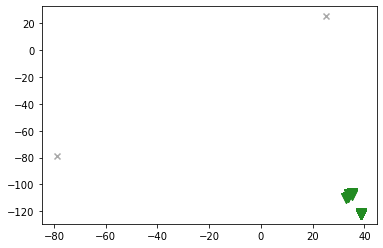

In [43]:
#y_test = np.hsplit(y_test, 2)
pred_test = np.hsplit(preds, 2)

plt.scatter(y_test[0], y_test[1], marker='v', s=100, color='forestgreen')
plt.scatter(preds[0], preds[1], color='darkgray', marker='x')

2/6/23 -- tutorial for multioutput practice

In [47]:
import argparse
from typing import Dict, Tuple, List

import numpy as np
from matplotlib import pyplot as plt
import xgboost as xgb

In [49]:
def plot_predt(y: np.ndarray, y_predt: np.ndarray, name: str) -> None:
    s = 25
    plt.scatter(y[:, 0], y[:, 1], c="navy", s=s, edgecolor="black", label="data")
    plt.scatter(
        y_predt[:, 0], y_predt[:, 1], c="cornflowerblue", s=s, edgecolor="black"
    )
    plt.xlim([-1, 2])
    plt.ylim([-1, 2])
    plt.show()

In [52]:
def gen_circle() -> Tuple[np.ndarray, np.ndarray]:
    "Generate a sample dataset that y is a 2 dim circle."
    rng = np.random.RandomState(1994)
    X = np.sort(200 * rng.rand(100, 1) - 100, axis=0)
    y = np.array([np.pi * np.sin(X).ravel(), np.pi * np.cos(X).ravel()]).T
    y[::5, :] += 0.5 - rng.rand(20, 2)
    y = y - y.min()
    y = y / y.max()
    return X, y

In [59]:
def rmse_model(plot_result: bool):
    """Draw a circle with 2-dim coordinate as target variables."""
    X, y = gen_circle()
    # Train a regressor on it
    reg = xgb.XGBRegressor(tree_method="hist", n_estimators=64)
    reg.fit(X, y, eval_set=[(X, y)])

    y_predt = reg.predict(X)
    if plot_result:
        plot_predt(y, y_predt, "multi")

In [60]:
def custom_rmse_model(plot_result: bool) -> None:
    """Train using Python implementation of Squared Error."""

    # As the experimental support status, custom objective doesn't support matrix as
    # gradient and hessian, which will be changed in future release.
    def gradient(predt: np.ndarray, dtrain: xgb.DMatrix) -> np.ndarray:
        """Compute the gradient squared error."""
        y = dtrain.get_label().reshape(predt.shape)
        return (predt - y).reshape(y.size)

    def hessian(predt: np.ndarray, dtrain: xgb.DMatrix) -> np.ndarray:
        """Compute the hessian for squared error."""
        return np.ones(predt.shape).reshape(predt.size)

    def squared_log(
        predt: np.ndarray, dtrain: xgb.DMatrix
    ) -> Tuple[np.ndarray, np.ndarray]:
        grad = gradient(predt, dtrain)
        hess = hessian(predt, dtrain)
        return grad, hess

    def rmse(predt: np.ndarray, dtrain: xgb.DMatrix) -> Tuple[str, float]:
        y = dtrain.get_label().reshape(predt.shape)
        v = np.sqrt(np.sum(np.power(y - predt, 2)))
        return "PyRMSE", v

In [ ]:
def custom_rmse_model(plot_result: bool) -> None:
    """Train using Python implementation of Squared Error."""

    # As the experimental support status, custom objective doesn't support matrix as
    # gradient and hessian, which will be changed in future release.
    def gradient(predt: np.ndarray, dtrain: xgb.DMatrix) -> np.ndarray:
        """Compute the gradient squared error."""
        y = dtrain.get_label().reshape(predt.shape)
        return (predt - y).reshape(y.size)

    def hessian(predt: np.ndarray, dtrain: xgb.DMatrix) -> np.ndarray:
        """Compute the hessian for squared error."""
        return np.ones(predt.shape).reshape(predt.size)

    def squared_log(
        predt: np.ndarray, dtrain: xgb.DMatrix
    ) -> Tuple[np.ndarray, np.ndarray]:
        grad = gradient(predt, dtrain)
        hess = hessian(predt, dtrain)
        return grad, hess

    def rmse(predt: np.ndarray, dtrain: xgb.DMatrix) -> Tuple[str, float]:
        y = dtrain.get_label().reshape(predt.shape)
        v = np.sqrt(np.sum(np.power(y - predt, 2)))
        return "PyRMSE", v

In [ ]:
    X, y = gen_circle()
    Xy = xgb.DMatrix(X, y)
    results: Dict[str, Dict[str, List[float]]] = {}
    # Make sure the `num_target` is passed to XGBoost when custom objective is used.
    # When builtin objective is used, XGBoost can figure out the number of targets
    # automatically.
    booster = xgb.train(
        {
            "tree_method": "hist",
            "num_target": y.shape[1],
        },
        dtrain=Xy,
        num_boost_round=100,
        obj=squared_log,
        evals=[(Xy, "Train")],
        evals_result=results,
        custom_metric=rmse,
    )

    y_predt = booster.inplace_predict(X)
    if plot_result:
        plot_predt(y, y_predt, "multi")


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--plot", choices=[0, 1], type=int, default=1)
    args = parser.parse_args()
    # Train with builtin RMSE objective
    rmse_model(args.plot == 1)
    # Train with custom objective.
    #custom_rmse_model(args.plot == 1)

https://machinelearningmastery.com/deep-learning-models-for-multi-output-regression/

In [10]:

# use mlp for prediction on multi-output regression
from numpy import asarray
from sklearn.datasets import make_regression
from keras.models import Sequential
from keras.layers import Dense

X = np.load('X.npy')
y = np.load('y.npy')
y_split = np.hsplit(y, 2)
data_dmatrix = xgb.DMatrix(data=X,label=y)


# get the model
def get_model(n_inputs, n_outputs):
 model = Sequential()
 model.add(Dense(20, input_dim=n_inputs, kernel_initializer='he_uniform', activation='relu'))
 model.add(Dense(n_outputs, kernel_initializer='he_uniform'))
 model.compile(loss='mae', optimizer='adam')
 return model
 
# load dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 1, shuffle=True)
    
# Scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test  = sc_X.transform(X_test)

#X, y = get_dataset() dont need for this example
n_inputs, n_outputs = X.shape[1], y.shape[1]
# get model
model = get_model(n_inputs, n_outputs)
# fit the model on all data
model <- model.fit(X, y, verbose=0, epochs=100)

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

train_error = np.round(rf.score(X_train, y_train), 2)
test_error = np.round(rf.score(X_test, y_test), 2)    
print("Training Set Mean Accuracy = " + str(train_error))
print("Test Set Mean Accuracy = " + str(test_error))

print("R2 = " + " " + str(r2_score(y_test,pred_test)))
print("mse = " + " " + str(mean_squared_error(y_test,pred_test)))

TypeError: bad operand type for unary -: 'History'

^C
  Using cached tensorflow-2.11.0-cp39-cp39-win_amd64.whl (1.9 kB)
  Using cached tensorflow_intel-2.11.0-cp39-cp39-win_amd64.whl (266.3 MB)
  Using cached protobuf-3.19.6-cp39-cp39-win_amd64.whl (895 kB)
  Using cached tensorflow_estimator-2.11.0-py2.py3-none-any.whl (439 kB)
  Using cached libclang-15.0.6.1-py2.py3-none-win_amd64.whl (23.2 MB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
  Using cached absl_py-1.4.0-py3-none-any.whl (126 kB)
  Using cached opt_einsum-3.3.0-py3-none-any.whl (65 kB)
  Using cached gast-0.4.0-py3-none-any.whl (9.8 kB)
  Using cached grpcio-1.51.1-cp39-cp39-win_amd64.whl (3.7 MB)
  Using cached h5py-3.8.0-cp39-cp39-win_amd64.whl (2.6 MB)
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
  Using cached wrapt-1.14.1-cp39-cp39-win_amd64.whl (35 kB)
  Using cached termcolor-2.2.0-py3-none-any.whl (6.6 kB)
  Using cached tensorboard-2.11.2-py3-none-any.whl (6.0 MB)
  Using cached tensorflow_io_gcs_filesystem-0.30.0-cp39-cp39-win_amd